<a href="https://colab.research.google.com/github/umair594/Remote-internship_DS_CodeAlpha/blob/main/Sales%20Prediction%20using%20Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Sales Prediction using Python**

# **Sales Prediction using Python**

# **Sales Prediction using Python**

# **Sales Prediction using Python**

# **Step 1: Problem Understanding**

**Goal:**

**Predict future sales based on:**

Advertising spend (TV, Radio, Social Media)

Target segment

Platform (Online, Offline)

This is a Regression Problem (predict continuous sales values)

# **Step 2: Import Libraries**

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# **Step 3: Load Dataset**

**You can use or create a dataset like:**

| TV | Radio | Social_Media | Platform | Segment | Sales |
| -- | ----- | ------------ | -------- | ------- | ----- |


In [60]:
df = pd.read_csv("Advertising.csv")
# Drop the 'Unnamed: 0' column as it is likely an artifact from saving.
df = df.drop(columns=['Unnamed: 0'], errors='ignore')
print(df.head())
print(df.info())

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None


# **Step 4: Data Preprocessing**

**Handle Missing Values**

In [58]:
df = df.dropna()

**# Encode Categorical Variables**

In [62]:
# Generate synthetic data for 'Social_Media', 'Platform', and 'Segment' to match problem description
df['Social_Media'] = np.random.uniform(0, 50, len(df))
df['Platform'] = np.random.choice(['Online', 'Offline'], len(df))
df['Segment'] = np.random.choice(['TargetA', 'TargetB', 'TargetC'], len(df))

le = LabelEncoder()

df['Platform'] = le.fit_transform(df['Platform'])
df['Segment'] = le.fit_transform(df['Segment'])

**Feature Selection**

In [63]:
X = df[['TV', 'Radio', 'Social_Media', 'Platform', 'Segment']]
y = df['Sales']

# **Step 5: Exploratory Data Analysis (EDA)**

**Correlation Heatmap**

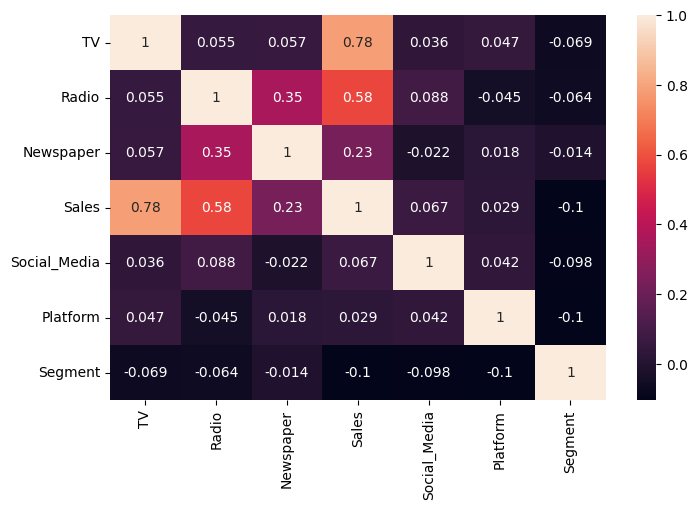

In [64]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True)
plt.show()

**Advertising vs Sales**

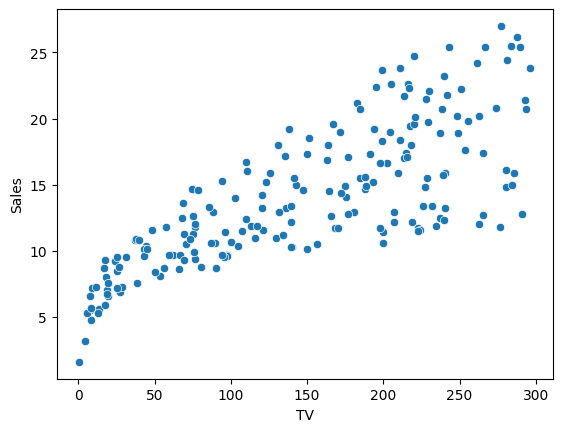

In [65]:
sns.scatterplot(x=df['TV'], y=df['Sales'])
plt.show()

**Helps identify:**

Which ad channel impacts sales most

Trends and relationships

# **Step 6: Train-Test Split**

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **Step 7: Feature Scaling**

In [67]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Step 8: Train Model**

**Linear Regression Model**

In [68]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

# **Step 9: Predictions**

In [69]:
y_pred = model.predict(X_test)

# **Step 10: Model Evaluation**

In [70]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1.4591425503162292
RMSE: 1.773759114080925
R2 Score: 0.9003211922031169


# **Step 11: Visualization of Results**

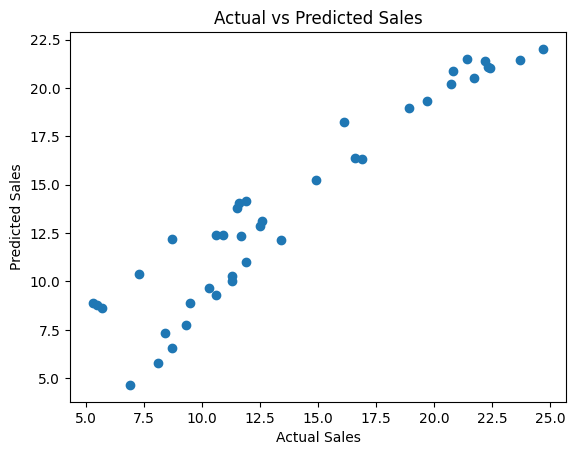

In [71]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

# **Step 12: Analyze Advertising Impact**

In [72]:
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coefficients)

              Coefficient
TV               3.763279
Radio            2.807405
Social_Media    -0.052396
Platform         0.005808
Segment         -0.129399


**Interpretation:**

Higher coefficient → stronger impact on sales

**Example**:

TV Ads = 0.8 → strong influence

Social Media = 0.3 → moderate

# **Step 13: Improve Model (Advanced)**

**Random Forest Regressor**

In [73]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("R2 Score (RF):", r2_score(y_test, y_pred_rf))

R2 Score (RF): 0.9840886179191809


# **Step 14: (Optional) Time Series Forecasting**

**If your dataset has date/time, use:**

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df['Sales'].plot()
plt.show()

**Then use models like:**

ARIMA

Prophet

# **Business Insights (IMPORTANT PART)**

**After training, you can conclude:**

Which advertising channel drives most sales
Optimal budget allocation
Platform performance (Online vs Offline)
Segment targeting effectiveness

# **Final Project Description (What You Learned)**

**Project: Sales Prediction using Machine Learning**

In this project, I developed a machine learning model to predict future sales based on advertising spend, target segments, and marketing platforms. The objective was to understand how different marketing strategies influence sales performance.

I started by collecting and preprocessing the dataset, which included handling missing values and encoding categorical variables such as platform and customer segments. I then performed exploratory data analysis (EDA) using visualization techniques to identify patterns and relationships between advertising channels and sales outcomes.

After preparing the data, I split it into training and testing sets and applied feature scaling to improve model performance. I trained a Linear Regression model to predict sales and evaluated its performance using metrics such as Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score.

To enhance prediction accuracy, I also experimented with advanced models like Random Forest Regressor. Additionally, I analyzed model coefficients to understand the impact of each advertising channel on sales, providing actionable business insights.

Through this project, I learned:
**bold text**
Data cleaning and preprocessing techniques
Feature selection and encoding methods
Regression modeling and evaluation
The impact of marketing strategies on sales
How to generate data-driven business insights

This project demonstrates how machine learning can be applied in real-world business scenarios to optimize marketing strategies and improve sales forecasting.